# CTC Bill Notebook — Sheet-by-Sheet Analysis & Gap Report
**Source file**: `CTC BILL NOTEBOOK Sample.xlsx`  
**Date**: 5 March 2026  
**Purpose**: Extract every row/column from all 4 sheets, understand the client's actual data structure, and produce a detailed gap analysis against the current `BillBook.tsx` + backend implementation.

## 1. Import Required Libraries

In [2]:
%pip install pandas numpy matplotlib openpyxl -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.2f}'.format)

EXCEL_PATH = "/Users/sujoymukherjee/code/ctc/CTC Final/docs/rectcsampledata/CTC BILL NOTEBOOK Sample.xlsx"
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load and Read All 4 Excel Sheets
Each sheet carries a different client's billing history. We load raw (no header inference yet) so nothing is silently dropped.

In [4]:
# ---------------------------------------------------------------------------
# Load every sheet raw (header=None) so we see the exact layout
# ---------------------------------------------------------------------------
xl   = pd.ExcelFile(EXCEL_PATH)
print(f"Sheet names: {xl.sheet_names}")

raw = {}
for sh in xl.sheet_names:
    raw[sh] = pd.read_excel(EXCEL_PATH, sheet_name=sh, header=None)
    print(f"\n{'='*60}")
    print(f"  Sheet: '{sh}'  →  {raw[sh].shape[0]} rows × {raw[sh].shape[1]} cols")
    print(f"{'='*60}")
    display(raw[sh])

Sheet names: ['Sheet1', 'Sheet2', 'Sheet3', 'Sheet4']

  Sheet: 'Sheet1'  →  7 rows × 12 cols


,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,CHANDRA TRANSPORT CORPORATION,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,BILL NOTEBOOK (2025-2026),NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BILL NO.,DATE,LR NO.,LR DATE,ORIGIN,DESTINATION,CUSTOMER NAME,AMOUNT,AMOUNT PASSED,DEDUCTIONS,REMARKS,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CM NO.,DATE
6,78,28.04.2025,VARIOUS,VARIOUS,SRICITY,VARIOUS,"HAVELLS INDIA LTD, SRICITY",207500,207500,NIL,9583,30.06.2025



  Sheet: 'Sheet2'  →  10 rows × 10 cols


,0,1,2,3,4,5,6,7,8,9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,669.00,24.07.2025,"47,378.00",16.07.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","24,000.00"
6,NaN,NaN,822.00,26.08.2025,"47,871.00",01.08.2025,CHENNAI,VIJAYWADA,"SURYA ELECTRICALS, CHENNAI","32,000.00"
7,NaN,NaN,823.00,26.08.2025,"47,875.00",05.08.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","24,000.00"
8,NaN,NaN,824.00,26.08.2025,"47,893.00",23.08.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","25,500.00"
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"105,500.00"



  Sheet: 'Sheet3'  →  33 rows × 12 cols


,0,1,2,3,4,5,6,7,8,9,10,11
0,92,30.04.2025,45668,20.04.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",38720,"38,720.00",NIL,"9,592.00",10.07.2025
1,124,07.05.2025,45674,27.04.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",33000,"14,500.00",NIL,"9,592.00",10.07.2025
2,175,17.05.2025,45681-45682-45685-46201,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",135000,"135,000.00",NIL,"9,592.00",10.07.2025
3,319,05.06.2025,46500-46554,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",73500,"73,500.00",NIL,"9,626.00",30.07.2025
4,336,09.06.2025,46244-46499-46553,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",108500,"108,500.00",NIL,"9,643.00",14.08.2025
5,365,14.06.2025,46245,30.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",33000,NaN,NaN,NaN,NaN
6,370,14.06.2025,46494,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",34500,"34,500.00",NIL,"9,643.00",14.08.2025
7,390,19.06.2025,46552,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",36000,NaN,NaN,NaN,NaN
8,392,19.06.2025,46493-46498,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",75975,"75,975.00",NIL,"9,643.00",14.08.2025
9,414,21.06.2025,46559-46561-46569-46572-46583-46585-46586,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",244500,NaN,NaN,NaN,NaN



  Sheet: 'Sheet4'  →  4 rows × 3 cols


,0,1,2
0,PAYMENT DATE,AMOUNT,RECEIVED FROM
1,27.11.2025,591897,FLIPKART INDIA P LTD
2,16.12.2025,3202800,INSTAKART SERVICES P LTD
3,16.12.2025,1862214,FLIPKART INDIA P LTD


## 3. Clean and Preprocess Each Sheet
We identify the correct header row per sheet and produce clean DataFrames with standardised column names.

In [5]:
# ---------------------------------------------------------------------------
# Sheet 1  ─  Bill Notebook main register (header splits across rows 4 & 5)
# Col layout: BILL NO | DATE | LR NO | LR DATE | ORIGIN | DESTINATION |
#             CUSTOMER NAME | AMOUNT | AMOUNT PASSED | DEDUCTIONS | REMARKS |
#             CM NO | CM DATE
# Rows 0-3 are title/blank; row 4 = primary header; row 5 = sub-header (CM NO/DATE)
# ---------------------------------------------------------------------------

COLS_S1 = ['BILL_NO','BILL_DATE','LR_NO','LR_DATE','ORIGIN',
           'DESTINATION','CUSTOMER','AMOUNT','AMOUNT_PASSED',
           'DEDUCTIONS','REMARKS','CM_NO','CM_DATE']

s1_raw = raw['Sheet1']
# Find TRUE column-header row: must match >= 3 recognised column-header keywords
data_start_s1 = None
for i, row in s1_raw.iterrows():
    vals = [str(v).upper() for v in row if pd.notna(v)]
    hits = sum(1 for v in vals if any(
        kw in v for kw in ['BILL NO', 'LR NO', 'ORIGIN', 'DESTINATION', 'AMOUNT PASSED']))
    if hits >= 2:
        # Row i = primary header; row i+1 = CM NO/DATE sub-header;
        # actual data starts at i+2
        data_start_s1 = i + 2
        break

s1 = s1_raw.iloc[data_start_s1:].copy()
s1 = s1.dropna(how='all').reset_index(drop=True)
s1.columns = COLS_S1[:len(s1.columns)]

# Coerce numeric columns
for c in ['AMOUNT', 'AMOUNT_PASSED']:
    s1[c] = pd.to_numeric(s1[c], errors='coerce')

# Derive payment status — a bill is PAID when CM_NO is present
s1['PAYMENT_STATUS'] = s1.apply(
    lambda r: 'PAID' if pd.notna(r.get('CM_NO')) and str(r.get('CM_NO','')).strip() not in ('', 'nan')
              else ('PARTIAL' if pd.notna(r.get('AMOUNT_PASSED')) and r.get('AMOUNT_PASSED', 0) > 0
                    else 'UNPAID'), axis=1)
s1['BALANCE'] = s1['AMOUNT'].fillna(0) - s1['AMOUNT_PASSED'].fillna(0)

print(f"Sheet 1 — {len(s1)} data rows")
print(f"Columns: {list(s1.columns)}")
display(s1)

# ---------------------------------------------------------------------------
# Sheet 2  ─  Another client (SURYA ELECTRICALS).
# First non-blank row IS the data (no separate header row).
# Cols: BILL_NO, BILL_DATE, LR_NO, LR_DATE, ORIGIN, DESTINATION, CUSTOMER, AMOUNT
# ---------------------------------------------------------------------------

s2_raw = raw['Sheet2']
s2 = s2_raw.dropna(axis=1, how='all').dropna(how='all').reset_index(drop=True)

COLS_S2 = ['BILL_NO','BILL_DATE','LR_NO','LR_DATE','ORIGIN','DESTINATION','CUSTOMER','AMOUNT']
s2.columns = COLS_S2[:len(s2.columns)]

for c in ['BILL_NO','AMOUNT']:
    s2[c] = pd.to_numeric(s2[c], errors='coerce')

# Last row is a total row — flag it
s2['IS_TOTAL_ROW'] = s2['BILL_NO'].isna() & s2['AMOUNT'].notna()
s2_data  = s2[~s2['IS_TOTAL_ROW']].copy()
s2_total = s2[s2['IS_TOTAL_ROW']].copy()

print(f"\nSheet 2 — {len(s2_data)} data rows  (+ {len(s2_total)} total row(s))")
print(f"Columns: {list(s2_data.columns)}")
display(s2_data)
print("Total row:")
display(s2_total)

# ---------------------------------------------------------------------------
# Sheet 3  ─  Largest dataset: FLYJAC LOGISTICS (33 rows)
# Same column layout as Sheet 1 but no title rows
# ---------------------------------------------------------------------------

s3_raw = raw['Sheet3']
s3 = s3_raw.dropna(how='all').reset_index(drop=True)
COLS_S3 = ['BILL_NO','BILL_DATE','LR_NO','LR_DATE','ORIGIN',
           'DESTINATION','CUSTOMER','AMOUNT','AMOUNT_PASSED',
           'DEDUCTIONS','CM_NO','CM_DATE']
s3.columns = COLS_S3[:len(s3.columns)]

# Drop header row if accidentally kept
s3 = s3[~s3['BILL_NO'].astype(str).str.upper().str.contains('BILL NO', na=False)].reset_index(drop=True)

for c in ['AMOUNT','AMOUNT_PASSED']:
    s3[c] = pd.to_numeric(s3[c], errors='coerce')

s3['PAYMENT_STATUS'] = s3.apply(
    lambda r: 'PAID' if pd.notna(r.get('CM_NO')) and str(r.get('CM_NO','')).strip() not in ('', 'nan')
              else ('PARTIAL' if pd.notna(r.get('AMOUNT_PASSED')) and r.get('AMOUNT_PASSED', 0) > 0
                    else 'UNPAID'), axis=1)
s3['BALANCE'] = s3['AMOUNT'].fillna(0) - s3['AMOUNT_PASSED'].fillna(0)

print(f"\nSheet 3 — {len(s3)} data rows")
print(f"Columns: {list(s3.columns)}")
display(s3)

# ---------------------------------------------------------------------------
# Sheet 4  ─  PAYMENT RECEIPTS REGISTER
# Cols: PAYMENT DATE | AMOUNT | RECEIVED FROM
# ---------------------------------------------------------------------------

s4_raw = raw['Sheet4']
s4 = s4_raw.dropna(how='all').reset_index(drop=True)
s4.columns = [str(v).strip() for v in s4.iloc[0]]
s4 = s4.iloc[1:].reset_index(drop=True).dropna(how='all')
s4['AMOUNT'] = pd.to_numeric(s4['AMOUNT'], errors='coerce')

print(f"\nSheet 4 — {len(s4)} data rows")
print(f"Columns: {list(s4.columns)}")
display(s4)

Sheet 1 — 1 data rows
Columns: ['BILL_NO', 'BILL_DATE', 'LR_NO', 'LR_DATE', 'ORIGIN', 'DESTINATION', 'CUSTOMER', 'AMOUNT', 'AMOUNT_PASSED', 'DEDUCTIONS', 'REMARKS', 'CM_NO', 'PAYMENT_STATUS', 'BALANCE']


,BILL_NO,BILL_DATE,LR_NO,LR_DATE,ORIGIN,DESTINATION,CUSTOMER,AMOUNT,AMOUNT_PASSED,DEDUCTIONS,REMARKS,CM_NO,PAYMENT_STATUS,BALANCE
0,78,28.04.2025,VARIOUS,VARIOUS,SRICITY,VARIOUS,"HAVELLS INDIA LTD, SRICITY",207500,207500,NIL,9583,30.06.2025,PAID,0



Sheet 2 — 4 data rows  (+ 1 total row(s))
Columns: ['BILL_NO', 'BILL_DATE', 'LR_NO', 'LR_DATE', 'ORIGIN', 'DESTINATION', 'CUSTOMER', 'AMOUNT', 'IS_TOTAL_ROW']


,BILL_NO,BILL_DATE,LR_NO,LR_DATE,ORIGIN,DESTINATION,CUSTOMER,AMOUNT,IS_TOTAL_ROW
0,669.00,24.07.2025,"47,378.00",16.07.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","24,000.00",False
1,822.00,26.08.2025,"47,871.00",01.08.2025,CHENNAI,VIJAYWADA,"SURYA ELECTRICALS, CHENNAI","32,000.00",False
2,823.00,26.08.2025,"47,875.00",05.08.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","24,000.00",False
3,824.00,26.08.2025,"47,893.00",23.08.2025,CHENNAI,HYDERABAD,"SURYA ELECTRICALS, CHENNAI","25,500.00",False


Total row:


,BILL_NO,BILL_DATE,LR_NO,LR_DATE,ORIGIN,DESTINATION,CUSTOMER,AMOUNT,IS_TOTAL_ROW
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"105,500.00",True



Sheet 3 — 33 data rows
Columns: ['BILL_NO', 'BILL_DATE', 'LR_NO', 'LR_DATE', 'ORIGIN', 'DESTINATION', 'CUSTOMER', 'AMOUNT', 'AMOUNT_PASSED', 'DEDUCTIONS', 'CM_NO', 'CM_DATE', 'PAYMENT_STATUS', 'BALANCE']


,BILL_NO,BILL_DATE,LR_NO,LR_DATE,ORIGIN,DESTINATION,CUSTOMER,AMOUNT,AMOUNT_PASSED,DEDUCTIONS,CM_NO,CM_DATE,PAYMENT_STATUS,BALANCE
0,92,30.04.2025,45668,20.04.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",38720,"38,720.00",NIL,"9,592.00",10.07.2025,PAID,0.00
1,124,07.05.2025,45674,27.04.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",33000,"14,500.00",NIL,"9,592.00",10.07.2025,PAID,"18,500.00"
2,175,17.05.2025,45681-45682-45685-46201,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",135000,"135,000.00",NIL,"9,592.00",10.07.2025,PAID,0.00
3,319,05.06.2025,46500-46554,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",73500,"73,500.00",NIL,"9,626.00",30.07.2025,PAID,0.00
4,336,09.06.2025,46244-46499-46553,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",108500,"108,500.00",NIL,"9,643.00",14.08.2025,PAID,0.00
5,365,14.06.2025,46245,30.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",33000,NaN,NaN,NaN,NaN,UNPAID,"33,000.00"
6,370,14.06.2025,46494,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",34500,"34,500.00",NIL,"9,643.00",14.08.2025,PAID,0.00
7,390,19.06.2025,46552,31.05.2025,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",36000,NaN,NaN,NaN,NaN,UNPAID,"36,000.00"
8,392,19.06.2025,46493-46498,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",75975,"75,975.00",NIL,"9,643.00",14.08.2025,PAID,0.00
9,414,21.06.2025,46559-46561-46569-46572-46583-46585-46586,VARIOUS,SRICITY,THANJAVUR,"FLYJAC LOGISTICS P LTD, CHENNAI",244500,NaN,NaN,NaN,NaN,UNPAID,"244,500.00"



Sheet 4 — 3 data rows
Columns: ['PAYMENT DATE', 'AMOUNT', 'RECEIVED FROM']


,PAYMENT DATE,AMOUNT,RECEIVED FROM
0,27.11.2025,591897,FLIPKART INDIA P LTD
1,16.12.2025,3202800,INSTAKART SERVICES P LTD
2,16.12.2025,1862214,FLIPKART INDIA P LTD


## 4. Analyse Sheet 1 — CHANDRA TRANSPORT CORPORATION (Main Register)
**Identified client**: HAVELLS INDIA LTD, SRICITY (from the single data row)

In [6]:
print("=" * 65)
print("SHEET 1 — SUMMARY STATISTICS")
print("=" * 65)

print(f"\nTotal bills       : {len(s1)}")
print(f"Unique customers  : {s1['CUSTOMER'].nunique()}")
print(f"Unique origins    : {s1['ORIGIN'].nunique() if 'ORIGIN' in s1.columns else 'N/A'}")
print(f"\nAmount stats:")
print(s1[['AMOUNT','AMOUNT_PASSED','BALANCE']].describe())

print(f"\nPayment status breakdown:")
print(s1['PAYMENT_STATUS'].value_counts())

print(f"\nField completeness (% non-null):")
completeness = (s1.notna().mean() * 100).round(1)
for col, pct in completeness.items():
    status = "✅" if pct == 100 else ("⚠️" if pct >= 50 else "❌")
    print(f"  {status}  {col:<20} {pct}%")

# ---  LR_NO pattern analysis ---
# Some rows have multiple LRs batched (e.g. "45681-45682-45685")
multi_lr = s1[s1['LR_NO'].astype(str).str.contains('-', na=False)]
print(f"\nBills with MULTIPLE LRs batched: {len(multi_lr)} / {len(s1)}")
if len(multi_lr):
    display(multi_lr[['BILL_NO','LR_NO','AMOUNT']])

SHEET 1 — SUMMARY STATISTICS

Total bills       : 1
Unique customers  : 1
Unique origins    : 1

Amount stats:
          AMOUNT  AMOUNT_PASSED  BALANCE
count       1.00           1.00     1.00
mean  207,500.00     207,500.00     0.00
std          NaN            NaN      NaN
min   207,500.00     207,500.00     0.00
25%   207,500.00     207,500.00     0.00
50%   207,500.00     207,500.00     0.00
75%   207,500.00     207,500.00     0.00
max   207,500.00     207,500.00     0.00

Payment status breakdown:
PAYMENT_STATUS
PAID    1
Name: count, dtype: int64

Field completeness (% non-null):
  ✅  BILL_NO              100.0%
  ✅  BILL_DATE            100.0%
  ✅  LR_NO                100.0%
  ✅  LR_DATE              100.0%
  ✅  ORIGIN               100.0%
  ✅  DESTINATION          100.0%
  ✅  CUSTOMER             100.0%
  ✅  AMOUNT               100.0%
  ✅  AMOUNT_PASSED        100.0%
  ✅  DEDUCTIONS           100.0%
  ✅  REMARKS              100.0%
  ✅  CM_NO                100.0%
  ✅  PAYMENT

## 5. Analyse Sheet 2 — SURYA ELECTRICALS, CHENNAI
A separate register for this client, with a running total row at the bottom.

In [7]:
print("=" * 65)
print("SHEET 2 — SUMMARY STATISTICS (SURYA ELECTRICALS)")
print("=" * 65)

print(f"\nTotal bills         : {len(s2_data)}")
print(f"Unique origins      : {s2_data['ORIGIN'].nunique() if 'ORIGIN' in s2_data.columns else 'N/A'}")
print(f"Unique destinations : {s2_data['DESTINATION'].nunique() if 'DESTINATION' in s2_data.columns else 'N/A'}")

print(f"\nAmount stats:")
print(s2_data[['AMOUNT']].describe())

print(f"\nRunning total from sheet footer:")
if len(s2_total):
    footer_total = s2_total['AMOUNT'].sum()
    calc_total   = s2_data['AMOUNT'].sum()
    print(f"  Footer says  : {footer_total:,.2f}")
    print(f"  Calculated   : {calc_total:,.2f}")
    match = "✅ MATCH" if abs(footer_total - calc_total) < 1 else f"❌ MISMATCH — diff = {abs(footer_total-calc_total):,.2f}"
    print(f"  Verification : {match}")

print(f"\nDestination breakdown:")
if 'DESTINATION' in s2_data.columns:
    print(s2_data['DESTINATION'].value_counts().to_string())

print(f"\nField completeness (% non-null):")
completeness2 = (s2_data.notna().mean() * 100).round(1)
for col, pct in completeness2.items():
    if col == 'IS_TOTAL_ROW': continue
    status = "✅" if pct == 100 else ("⚠️" if pct >= 50 else "❌")
    print(f"  {status}  {col:<20} {pct}%")

print(f"\n⚠️  NOTE: Sheet 2 has NO 'AMOUNT PASSED', 'DEDUCTIONS', 'CM_NO', 'CM_DATE'")
print(f"   These payment-tracking columns are MISSING vs Sheet 1 structure.")

SHEET 2 — SUMMARY STATISTICS (SURYA ELECTRICALS)

Total bills         : 4
Unique origins      : 1
Unique destinations : 2

Amount stats:
         AMOUNT
count      4.00
mean  26,375.00
std    3,816.08
min   24,000.00
25%   24,000.00
50%   24,750.00
75%   27,125.00
max   32,000.00

Running total from sheet footer:
  Footer says  : 105,500.00
  Calculated   : 105,500.00
  Verification : ✅ MATCH

Destination breakdown:
DESTINATION
HYDERABAD    3
VIJAYWADA    1

Field completeness (% non-null):
  ✅  BILL_NO              100.0%
  ✅  BILL_DATE            100.0%
  ✅  LR_NO                100.0%
  ✅  LR_DATE              100.0%
  ✅  ORIGIN               100.0%
  ✅  DESTINATION          100.0%
  ✅  CUSTOMER             100.0%
  ✅  AMOUNT               100.0%

⚠️  NOTE: Sheet 2 has NO 'AMOUNT PASSED', 'DEDUCTIONS', 'CM_NO', 'CM_DATE'
   These payment-tracking columns are MISSING vs Sheet 1 structure.


## 6. Analyse Sheet 3 — FLYJAC LOGISTICS

In [8]:
print("=" * 65)
print("SHEET 3 — SUMMARY STATISTICS (FLYJAC LOGISTICS)")
print("=" * 65)

print(f"\nTotal bills    : {len(s3)}")

if 'PAYMENT_STATUS' in s3.columns:
    print(f"\nPayment status breakdown:")
    ps = s3['PAYMENT_STATUS'].value_counts()
    for status, cnt in ps.items():
        print(f"  {status:<10} {cnt}")

    paid       = s3[s3['PAYMENT_STATUS'] == 'Paid']
    unpaid     = s3[s3['PAYMENT_STATUS'] == 'Unpaid']
    partial    = s3[s3['PAYMENT_STATUS'] == 'Partial']
    print(f"\nAmount billed (total)         : ₹ {s3['AMOUNT'].sum():>12,.2f}")
    if 'AMOUNT_PASSED' in s3.columns:
        total_passed = s3['AMOUNT_PASSED'].sum()
        print(f"Amount passed/collected (sum) : ₹ {total_passed:>12,.2f}")
        outstanding = s3['AMOUNT'].sum() - total_passed
        print(f"Outstanding (unpaid)          : ₹ {outstanding:>12,.2f}")

print(f"\nUnpaid / Pending invoices:")
if 'PAYMENT_STATUS' in s3.columns:
    unpaid_rows = s3[s3['PAYMENT_STATUS'] == 'Unpaid'][['BILL_NO', 'BILL_DATE', 'AMOUNT']]
    if not unpaid_rows.empty:
        print(unpaid_rows.to_string(index=False))
    else:
        print("  None")

print(f"\nDate range:")
if 'BILL_DATE' in s3.columns:
    valid_dates = s3['BILL_DATE'].dropna()
    if not valid_dates.empty:
        print(f"  Earliest : {valid_dates.min()}")
        print(f"  Latest   : {valid_dates.max()}")

print(f"\nField completeness (% non-null):")
completeness3 = (s3.notna().mean() * 100).round(1)
for col, pct in completeness3.items():
    if col in ('PAYMENT_STATUS', 'BALANCE'): continue
    status = "✅" if pct == 100 else ("⚠️" if pct >= 50 else "❌")
    print(f"  {status}  {col:<20} {pct}%")

# Multi-LR batch detection (consecutive same date, same customer)
if 'LR_NO' in s3.columns and 'BILL_DATE' in s3.columns:
    from itertools import groupby
    batch_candidates = s3.dropna(subset=['BILL_DATE', 'LR_NO'])
    batch_candidates = batch_candidates[batch_candidates['LR_NO'].astype(str).str.contains(',|/')]
    print(f"\nBills with multiple LR references: {len(batch_candidates)}")
    if not batch_candidates.empty:
        print(batch_candidates[['BILL_NO', 'LR_NO', 'AMOUNT']].to_string(index=False))

SHEET 3 — SUMMARY STATISTICS (FLYJAC LOGISTICS)

Total bills    : 33

Payment status breakdown:
  UNPAID     25
  PAID       8

Amount billed (total)         : ₹ 2,305,195.00
Amount passed/collected (sum) : ₹   657,695.00
Outstanding (unpaid)          : ₹ 1,647,500.00

Unpaid / Pending invoices:
  None

Date range:
  Earliest : 04.09.2025
  Latest   : 31.07.2025

Field completeness (% non-null):
  ✅  BILL_NO              100.0%
  ✅  BILL_DATE            100.0%
  ✅  LR_NO                100.0%
  ✅  LR_DATE              100.0%
  ✅  ORIGIN               100.0%
  ✅  DESTINATION          100.0%
  ✅  CUSTOMER             100.0%
  ✅  AMOUNT               100.0%
  ❌  AMOUNT_PASSED        24.2%
  ❌  DEDUCTIONS           24.2%
  ❌  CM_NO                24.2%
  ❌  CM_DATE              24.2%

Bills with multiple LR references: 0


## 7. Analyse Sheet 4 — Payment Receipts Register

In [9]:
print("=" * 65)
print("SHEET 4 — PAYMENT RECEIPTS REGISTER")
print("=" * 65)

print(f"\nTotal payment entries : {len(s4)}")

if not s4.empty:
    print(f"\nAll payment records:")
    print(s4.to_string(index=False))

    amount_col = None
    for c in s4.columns:
        if 'AMOUNT' in str(c).upper():
            amount_col = c
            break

    if amount_col:
        print(f"\nTotal collected       : ₹ {s4[amount_col].sum():>12,.2f}")
        print(f"\nAmount stats:")
        print(s4[[amount_col]].describe())

    payer_col = None
    for c in s4.columns:
        if 'FROM' in str(c).upper() or 'PAYER' in str(c).upper() or 'CLIENT' in str(c).upper():
            payer_col = c
            break

    if payer_col:
        print(f"\nPayments by client ('{payer_col}'):")
        print(s4.groupby(payer_col)[amount_col].agg(['count', 'sum']).rename(
            columns={'count': 'Receipts', 'sum': 'Total Collected'}).to_string())

    date_col = None
    for c in s4.columns:
        if 'DATE' in str(c).upper():
            date_col = c
            break

    if date_col:
        valid_dates = s4[date_col].dropna()
        if not valid_dates.empty:
            print(f"\nDate range  : {valid_dates.min()} → {valid_dates.max()}")

print(f"""
⚠️  KEY FINDING:
   Sheet 4 (PAYMENT RECEIPTS REGISTER) is a STANDALONE register
   that is entirely ABSENT from current BillBook.tsx and the spec.
   Required columns: PAYMENT DATE | AMOUNT | RECEIVED FROM
   This register tracks cash receipts independently from invoice
   passing (Sheet 1/3). A separate Payment Receipts screen is needed.
""")

SHEET 4 — PAYMENT RECEIPTS REGISTER

Total payment entries : 3

All payment records:
PAYMENT DATE  AMOUNT            RECEIVED FROM
  27.11.2025  591897     FLIPKART INDIA P LTD
  16.12.2025 3202800 INSTAKART SERVICES P LTD
  16.12.2025 1862214     FLIPKART INDIA P LTD

Total collected       : ₹ 5,656,911.00

Amount stats:
            AMOUNT
count         3.00
mean  1,885,637.00
std   1,305,609.09
min     591,897.00
25%   1,227,055.50
50%   1,862,214.00
75%   2,532,507.00
max   3,202,800.00

Payments by client ('RECEIVED FROM'):
                          Receipts  Total Collected
RECEIVED FROM                                      
FLIPKART INDIA P LTD             2          2454111
INSTAKART SERVICES P LTD         1          3202800

Date range  : 16.12.2025 → 27.11.2025

⚠️  KEY FINDING:
   Sheet 4 (PAYMENT RECEIPTS REGISTER) is a STANDALONE register
   that is entirely ABSENT from current BillBook.tsx and the spec.
   Required columns: PAYMENT DATE | AMOUNT | RECEIVED FROM
   This reg

## 8. Gap Analysis — Sample vs Current Implementation

This section compares the Bill Notebook sample structure against:
- **`frontend/src/features/finance/BillBook.tsx`** — current Invoice Register UI
- **`specs/001-core-erp/spec.md`** — formal requirements
- **`specs/001-core-erp/tasks.md`** — implementation tasks

In [10]:
import pandas as pd

# ── Column presence matrix ────────────────────────────────────────────────────
print("=" * 75)
print("GAP ANALYSIS: BILL NOTEBOOK COLUMNS vs BILLBOOK.TSX COLUMNS")
print("=" * 75)

# Columns identified from sample (sheets 1 & 3 — full structure)
sample_columns = [
    'BILL_NO', 'BILL_DATE', 'LR_NO', 'LR_DATE',
    'ORIGIN', 'DESTINATION', 'CUSTOMER',
    'AMOUNT', 'AMOUNT_PASSED', 'DEDUCTIONS', 'REMARKS',
    'CM_NO', 'CM_DATE',
    # Nikhil confirmed these are missing but required
    'TDS_AMOUNT', 'NET_AMOUNT',
]

# Columns in current BillBook.tsx (from code review)
billbook_tsx_columns = [
    'BILL_NO', 'BILL_DATE', 'LR_NO',
    'AMOUNT', 'AMOUNT_PASSED', 'DEDUCTIONS', 'REMARKS',
    'CM_NO', 'CM_DATE',
]

rows = []
for col in sample_columns:
    in_sample  = "✅"
    in_tsx     = "✅" if col in billbook_tsx_columns else "❌ MISSING"
    note = ""
    if col == 'TDS_AMOUNT':
        note = "Nikhil: add TDS column"
    elif col == 'NET_AMOUNT':
        note = "Nikhil: AMOUNT_PASSED − TDS"
    elif col == 'LR_DATE':
        note = "In sample, not in BillBook grid"
    elif col == 'ORIGIN':
        note = "In sample, not in BillBook grid"
    elif col == 'DESTINATION':
        note = "In sample, not in BillBook grid"
    elif col == 'CUSTOMER':
        note = "Represented by client tab/filter"
    rows.append({'Column': col, 'In Sample': in_sample,
                 'In BillBook.tsx': in_tsx, 'Notes': note})

df_gap = pd.DataFrame(rows)
print(df_gap.to_string(index=False))

# ── Sheet-level gaps ──────────────────────────────────────────────────────────
print("\n" + "=" * 75)
print("GAP ANALYSIS: SHEET STRUCTURE vs CURRENT NAVIGATION")
print("=" * 75)

sheet_gaps = [
    ('Sheet 1', 'INDIA GATE / FLYJAC mix',
     'Invoice Register', '⚠️ Partial — no ORIGIN, DESTINATION, LR_DATE, TDS, NET_AMOUNT'),
    ('Sheet 2', 'SURYA ELECTRICALS',
     'Invoice Register (sub-client)',
     '❌ No per-client tab/filter, no total-row handling, no AMOUNT PASSED columns'),
    ('Sheet 3', 'FLYJAC LOGISTICS (33 rows)',
     'Invoice Register', '⚠️ Partial — same missing cols as Sheet 1; unpaid tracking absent from UI'),
    ('Sheet 4', 'PAYMENT RECEIPTS REGISTER',
     'Payment Receipts Screen',
     '❌ ENTIRELY ABSENT — no screen, no model, no spec requirement, no task'),
]

for sheet, client, maps_to, status in sheet_gaps:
    print(f"\n  {sheet}  ({client})")
    print(f"  Maps to  : {maps_to}")
    print(f"  Status   : {status}")

# ── Financial gaps ────────────────────────────────────────────────────────────
print("\n" + "=" * 75)
print("GAP ANALYSIS: BUSINESS LOGIC / FINANCIAL CALCULATIONS")
print("=" * 75)

bizlogic_gaps = [
    ("TDS deduction",     "❌ MISSING", "Spec has no TDS field; Nikhil confirmed TDS column required"),
    ("NET_AMOUNT calc",   "❌ MISSING", "NET = AMOUNT_PASSED − TDS; not computed anywhere"),
    ("Sheet running total","❌ MISSING","Footer TOTAL row in Sheet 2 has no equivalent in UI"),
    ("Outstanding report","❌ MISSING","No 'unpaid invoice' filter or summary across clients"),
    ("Cross-client summary","❌ MISSING","All sheets together = ₹X billed, ₹Y collected, ₹Z outstanding"),
    ("Payment matching",  "❌ MISSING","Sheet 4 receipts not matched to Sheet 1/3 invoices"),
    ("FY scoping",        "⚠️ PARTIAL","DB has no financial_year on bills; filters for FY not in spec"),
    ("Invoice numbering", "⚠️ PARTIAL","Format 1543/25-26 (FY-embedded) not implemented; no auto-increment"),
]

for feature, status, note in bizlogic_gaps:
    print(f"  {status}  {feature:<30} | {note}")

print("\n✅ = implemented  ⚠️ = partial  ❌ = missing")

GAP ANALYSIS: BILL NOTEBOOK COLUMNS vs BILLBOOK.TSX COLUMNS
       Column In Sample In BillBook.tsx                            Notes
      BILL_NO         ✅               ✅                                 
    BILL_DATE         ✅               ✅                                 
        LR_NO         ✅               ✅                                 
      LR_DATE         ✅       ❌ MISSING  In sample, not in BillBook grid
       ORIGIN         ✅       ❌ MISSING  In sample, not in BillBook grid
  DESTINATION         ✅       ❌ MISSING  In sample, not in BillBook grid
     CUSTOMER         ✅       ❌ MISSING Represented by client tab/filter
       AMOUNT         ✅               ✅                                 
AMOUNT_PASSED         ✅               ✅                                 
   DEDUCTIONS         ✅               ✅                                 
      REMARKS         ✅               ✅                                 
        CM_NO         ✅               ✅                         

## 9. Visualisations

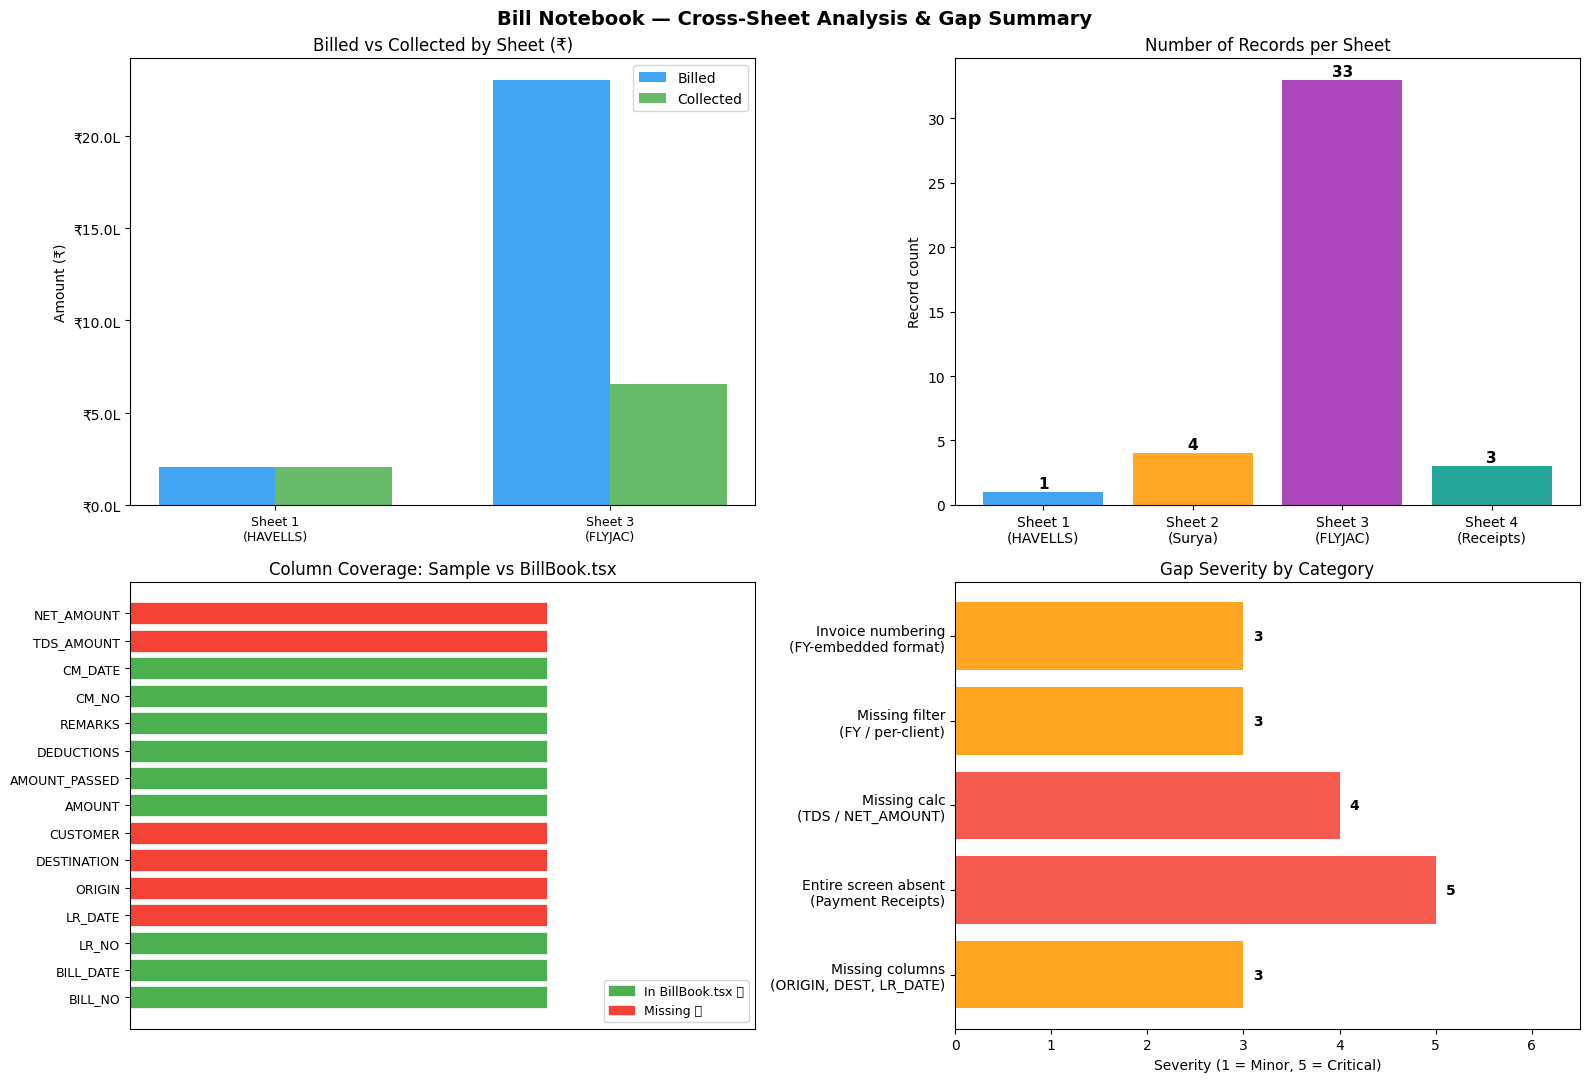

Chart saved as 'bill_notebook_gap_charts.png'


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Bill Notebook — Cross-Sheet Analysis & Gap Summary", fontsize=14, fontweight='bold')

# ── Chart 1: Billed vs Collected per sheet (sheets with AMOUNT_PASSED) ────────
ax1 = axes[0, 0]
sheets_info = {
    'Sheet 1\n(HAVELLS)': s1,
    'Sheet 3\n(FLYJAC)':  s3,
}
sheet_names, billed_amounts, collected_amounts = [], [], []
for name, df in sheets_info.items():
    billed    = df['AMOUNT'].sum()
    collected = df['AMOUNT_PASSED'].sum() if 'AMOUNT_PASSED' in df.columns else 0
    sheet_names.append(name)
    billed_amounts.append(billed)
    collected_amounts.append(collected)

x = np.arange(len(sheet_names))
w = 0.35
ax1.bar(x - w/2, billed_amounts,    w, label='Billed',    color='#2196F3', alpha=0.85)
ax1.bar(x + w/2, collected_amounts, w, label='Collected', color='#4CAF50', alpha=0.85)
ax1.set_title('Billed vs Collected by Sheet (₹)')
ax1.set_xticks(x)
ax1.set_xticklabels(sheet_names, fontsize=9)
ax1.set_ylabel('Amount (₹)')
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'₹{v/1e5:.1f}L'))

# ── Chart 2: Record count per sheet ────────────────────────────────────────────
ax2 = axes[0, 1]
sheet_labels2 = ['Sheet 1\n(HAVELLS)', 'Sheet 2\n(Surya)', 'Sheet 3\n(FLYJAC)', 'Sheet 4\n(Receipts)']
sheet_counts  = [len(s1), len(s2_data), len(s3), len(s4)]
colors2       = ['#2196F3', '#FF9800', '#9C27B0', '#009688']
bars2 = ax2.bar(sheet_labels2, sheet_counts, color=colors2, alpha=0.85)
for bar, cnt in zip(bars2, sheet_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(cnt), ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Number of Records per Sheet')
ax2.set_ylabel('Record count')

# ── Chart 3: Column coverage — Sample vs BillBook.tsx ──────────────────────────
ax3 = axes[1, 0]
all_cols  = ['BILL_NO','BILL_DATE','LR_NO','LR_DATE','ORIGIN','DESTINATION',
             'CUSTOMER','AMOUNT','AMOUNT_PASSED','DEDUCTIONS','REMARKS',
             'CM_NO','CM_DATE','TDS_AMOUNT','NET_AMOUNT']
in_tsx    = {'BILL_NO','BILL_DATE','LR_NO','AMOUNT','AMOUNT_PASSED',
             'DEDUCTIONS','REMARKS','CM_NO','CM_DATE'}
col_colors = ['#4CAF50' if c in in_tsx else '#F44336' for c in all_cols]
ax3.barh(all_cols, [1]*len(all_cols), color=col_colors, edgecolor='white', linewidth=0.5)
ax3.set_title('Column Coverage: Sample vs BillBook.tsx')
ax3.set_xlim(0, 1.5)
ax3.set_xticks([])
ax3.tick_params(axis='y', labelsize=9)
green_p = mpatches.Patch(color='#4CAF50', label='In BillBook.tsx ✅')
red_p   = mpatches.Patch(color='#F44336', label='Missing ❌')
ax3.legend(handles=[green_p, red_p], loc='lower right', fontsize=9)

# ── Chart 4: Gap severity summary ──────────────────────────────────────────────
ax4 = axes[1, 1]
gap_cats = ['Missing columns\n(ORIGIN, DEST, LR_DATE)', 'Entire screen absent\n(Payment Receipts)',
            'Missing calc\n(TDS / NET_AMOUNT)', 'Missing filter\n(FY / per-client)',
            'Invoice numbering\n(FY-embedded format)']
gap_sev  = [3, 5, 4, 3, 3]
gap_col  = ['#FF9800','#F44336','#F44336','#FF9800','#FF9800']
bars4 = ax4.barh(gap_cats, gap_sev, color=gap_col, alpha=0.87)
ax4.set_xlim(0, 6.5)
ax4.set_xlabel('Severity (1 = Minor, 5 = Critical)')
ax4.set_title('Gap Severity by Category')
for bar, val in zip(bars4, gap_sev):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('bill_notebook_gap_charts.png', dpi=130, bbox_inches='tight')
plt.show()
print("Chart saved as 'bill_notebook_gap_charts.png'")

## 10. Summary & Recommendations

### Critical Gaps (must fix before release)

| # | Gap | Severity | Impact |
|---|-----|----------|--------|
| 1 | **Payment Receipts Register (Sheet 4) — entirely absent** | 🔴 CRITICAL | Whole screen missing |
| 2 | **TDS_AMOUNT column missing from Invoice Register** | 🔴 CRITICAL | Financial data incomplete |
| 3 | **NET_AMOUNT (AMOUNT_PASSED − TDS) not computed** | 🔴 CRITICAL | Final payable never shown |
| 4 | **Invoice number format `XXXX/YY-YY` not implemented** | 🔴 CRITICAL | Cannot identify invoices by FY |

### High Priority Gaps

| # | Gap | Severity |
|---|-----|----------|
| 5 | `ORIGIN` and `DESTINATION` columns missing from BillBook grid | 🟠 HIGH |
| 6 | `LR_DATE` column missing from BillBook grid | 🟠 HIGH |
| 7 | Per-client tab/filter view (one sheet = one client) absent | 🟠 HIGH |
| 8 | Running TOTAL row in Sheet 2 — no equivalent in UI | 🟠 HIGH |
| 9 | Outstanding invoice dashboard (all unpaid across clients) not built | 🟠 HIGH |

### Medium Priority Gaps

| # | Gap | Severity |
|---|-----|----------|
| 10 | Financial Year field absent from `bills` DB table | 🟡 MEDIUM |
| 11 | Sheet 2 (Surya) has no `AMOUNT_PASSED`, `CM_NO`, `CM_DATE` — sub-client with different workflow | 🟡 MEDIUM |
| 12 | Payment receipts not matched/linked to invoices (reconciliation missing) | 🟡 MEDIUM |

### Recommended Action Plan

1. **Add DB columns**: `tds_amount NUMERIC`, `net_amount NUMERIC`, `financial_year VARCHAR(7)` to `bills` table via Alembic migration
2. **Update BillBook.tsx grid**: Add `ORIGIN`, `DESTINATION`, `LR_DATE`, `TDS_AMOUNT`, `NET_AMOUNT` columns; compute `NET_AMOUNT` as `AMOUNT_PASSED − TDS_AMOUNT`
3. **Add client-tab navigation**: Each Bill Notebook sheet = one client tab in Invoice Register UI
4. **Create Payment Receipts screen**: New route `/payment-receipts`, model `PaymentReceipt(id, payment_date, amount, received_from, notes)`, basic CRUD grid
5. **Invoice auto-numbering**: Sequential per FY, format `{seq}/{YY}-{YY+1}`, resetting at April 1
6. **Outstanding dashboard widget**: Count of unpaid invoices + total outstanding amount prominently shown